# Allineamento dell'immagine intera

Questo notebook ha l'obiettivo di allineare l'immagine intera (20000x20000) trovando la matrice di trasforazione sulla stessa immagine scalata a metà risoluzione (10000x10000).

# Definizioni iniziali

#### Pacchetti

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Allineamento

#### Apertura delle immagini intere

In [11]:
label_free = cv2.imread("../../Materiale/Locale/fullsize_label_free.tif")
mask_lf = cv2.imread("../../Materiale/Immagini/mask_label_free.tif", cv2.IMREAD_GRAYSCALE)
stained = cv2.imread("../../Materiale/Locale/fullsize_stained.tif")
mask_st = cv2.imread("../../Materiale/Immagini/mask_stained.tif", cv2.IMREAD_GRAYSCALE)

#### Scalatura delle immagini 

In [12]:
scale = 0.5
scaled_label_free = cv2.resize(label_free, None, fx=scale, fy=scale)
scaled_mask_lf = cv2.resize(mask_lf, None, fx=scale, fy=scale)
scaled_stained = cv2.resize(stained, None, fx=scale, fy=scale)
scaled_mask_st = cv2.resize(mask_st, None, fx=scale, fy=scale)

#### Calcolo della matrice di trasformazione

In [ ]:
# Applicazione di CLAHE
clahe = cv2.createCLAHE(clipLimit=18.0, tileGridSize=(8, 8))
label_free_clahe = clahe.apply(cv2.cvtColor(scaled_label_free, cv2.COLOR_BGR2GRAY))
stained_clahe = clahe.apply(cv2.cvtColor(scaled_stained, cv2.COLOR_BGR2GRAY))

# Rilevamento di keypoint e descrittori con SIFT
sift = cv2.SIFT_create(nfeatures=10000)
keypoints_1, descriptors_1 = sift.detectAndCompute(label_free_clahe, mask=scaled_mask_lf)
keypoints_2, descriptors_2 = sift.detectAndCompute(stained_clahe, mask=scaled_mask_st)

# Matching dei descrittori
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors_1, descriptors_2)

# Filtraggio dei matches con la distanza euclidea
filtered_matches = []
for match in matches:
    distance = np.linalg.norm(np.array(keypoints_1[match.queryIdx].pt) - np.array(keypoints_2[match.trainIdx].pt))
    if distance < 200:  # Soglia di distanza
        filtered_matches.append(match)

# Estrazione dei punti
points_1 = np.float32([keypoints_1[m.queryIdx].pt for m in filtered_matches]).reshape(-1, 1, 2)
points_2 = np.float32([keypoints_2[m.trainIdx].pt for m in filtered_matches]).reshape(-1, 1, 2)

# Calcolo della matrice di trasformazione
warp_matrix, inliers = cv2.estimateAffinePartial2D(points_2, points_1)
print("Matrice di trasformazione:\n", warp_matrix)

Matrice di trasformazione:
 [[ 1.00016406e+00  2.60373513e-03 -5.87369184e+00]
 [-2.60373513e-03  1.00016406e+00 -4.01905702e+01]]


#### Ridimensionamento della matrice di trasformazione per l'immagine originale

La terza colonna della matrice di trasformazione indica la traslazione in pixel, che va riadattata per l'immagine originale. Nel nostro caso l'immagine originale ha risoluzione doppia rispetto a quella per cui è stata calcolata la matrice, quindi va raddoppiata la terza colonna della matrice.

In [14]:
warp_matrix[0, 2] = warp_matrix[0, 2] / scale
warp_matrix[1, 2] = warp_matrix[1, 2] / scale
print("Matrice di trasformazione scalata:\n", warp_matrix)

Matrice di trasformazione scalata:
 [[ 1.00016406e+00  2.60373513e-03 -1.17473837e+01]
 [-2.60373513e-03  1.00016406e+00 -8.03811403e+01]]


#### Allineamento dell'immagine originale

In [15]:
aligned_stained = cv2.warpAffine(stained, warp_matrix, (label_free.shape[1], label_free.shape[0]))
algined_mask_st = cv2.warpAffine(mask_st, warp_matrix, (label_free.shape[1], label_free.shape[0]))

#### Salvataggio delle immagini allineate

In [16]:
cv2.imwrite("../../Materiale/Locale/aligned_stained.tif", aligned_stained)
cv2.imwrite("../../Materiale/Immagini/aligned_mask_stained.tif", algined_mask_st)

True

#### Visualizzazione dei risultati

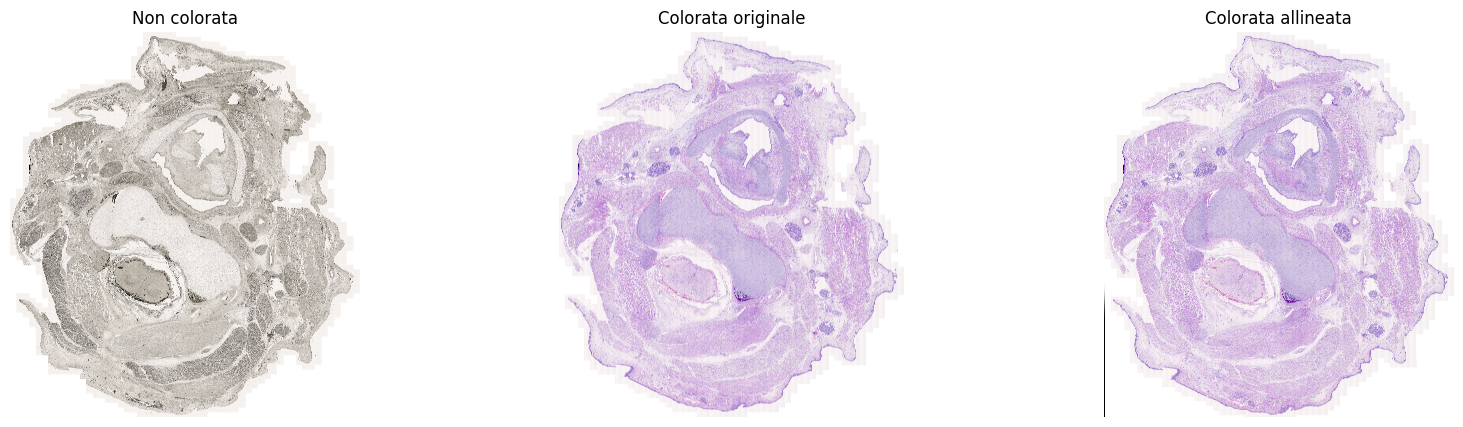

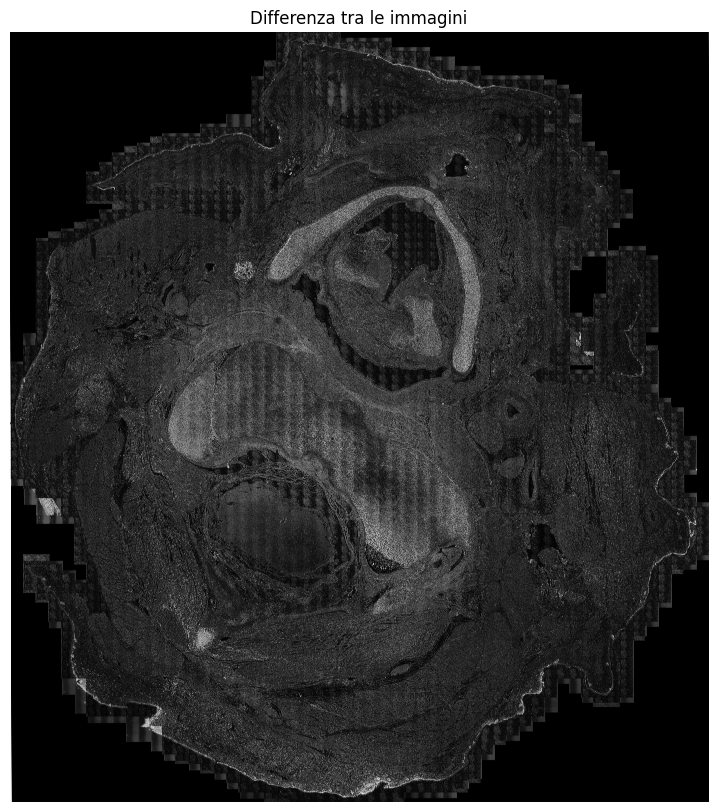

In [17]:
_label_free = cv2.cvtColor(label_free, cv2.COLOR_BGR2RGB)
_stained = cv2.cvtColor(stained, cv2.COLOR_BGR2RGB)
_aligned_stained = cv2.cvtColor(aligned_stained, cv2.COLOR_BGR2RGB)

figure, subplots = plt.subplots(1, 3, figsize=(20, 5))
subplots[0].imshow(_label_free)
subplots[0].set_title("Non colorata")
subplots[0].axis("off")
subplots[1].imshow(_stained)
subplots[1].set_title("Colorata originale")
subplots[1].axis("off")
subplots[2].imshow(_aligned_stained)
subplots[2].set_title("Colorata allineata")
subplots[2].axis("off")
plt.show()

# Calcolo della differenza tra le immagini
difference = cv2.absdiff(
    clahe.apply(cv2.cvtColor(label_free, cv2.COLOR_BGR2GRAY)),
    clahe.apply(cv2.cvtColor(aligned_stained, cv2.COLOR_BGR2GRAY)))

figure, axes = plt.subplots(figsize=(20, 10))
axes.imshow(difference, cmap="gray")
axes.set_title("Differenza tra le immagini")
axes.axis("off")
plt.show()